In [1]:
"""
Implement better simulations using frequency domain interpolation
"""

'\nImplement better simulations using frequency domain interpolation\n'

In [2]:
import numpy as np
from util.DataGen import nai_pulse, sample_shift_to_phase_shift, continuous_time_trace
import scipy
import matplotlib.pyplot as plt

from scipy.fft import fft, ifft

Pulse Peak Offset: 9
100 1250


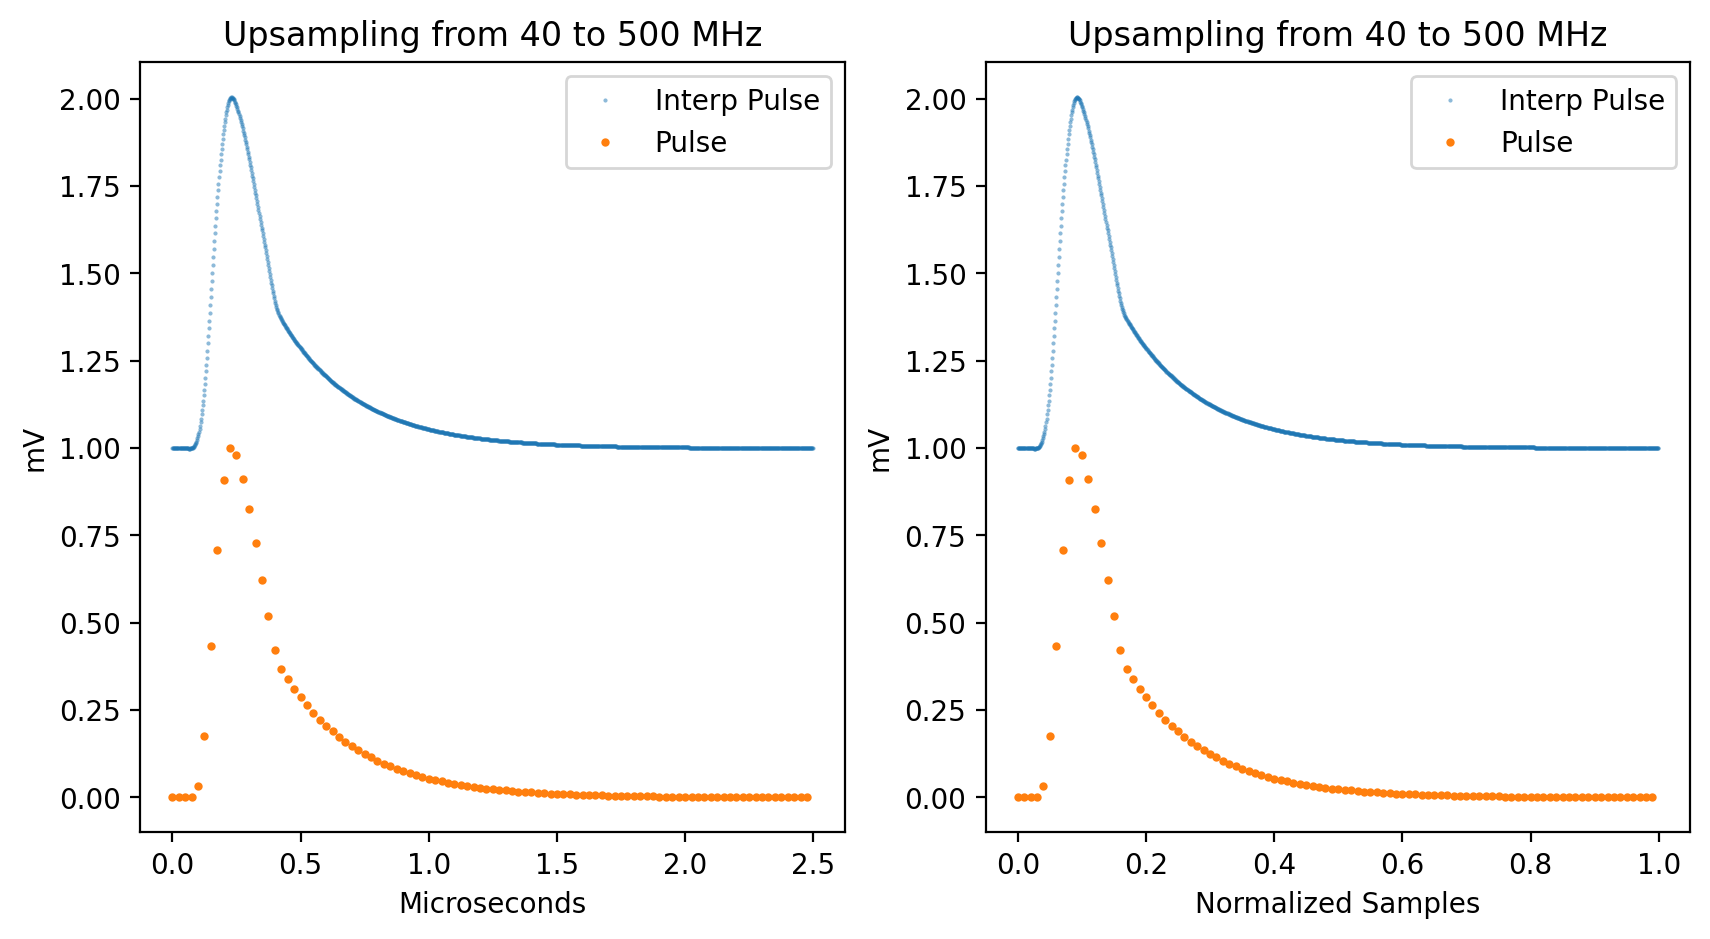

In [3]:
pulse_times, pulse = nai_pulse(1)
pulse_times = pulse_times[:-1]
pulse = pulse[:-1]
print('Pulse Peak Offset:', np.argmax(pulse))

# using scipy resample_poly for pulse interpolation as a temporary measure because I am struggling
# to get regular re-sample to work right for arbitrary frequnecy ratios

###########################################################

# old = 40
# new = 90
# ratio = new / old
# 
# assert ratio > 1 # asusming we are upsampling. I havent thought about less than one
# 
# # find lowest common multiple what keeps all numbers as integers
# if int(ratio) == ratio:
#     lcm = int(ratio)
# else:
#     # Surely there is an easier way to do this numerically...
#     lcm = 1
#     while int(lcm * ratio) != lcm * ratio: lcm += 1
# 
# print('Ratio', ratio, 'lcm', lcm)
# print('pulse.size', pulse.size)
# 
# # Build padded pulse to
# pad_pulse = np.zeros(int(lcm * pulse.size))
# pad_pulse[:pulse.size] = pulse
# pad_times = np.arange(pulse.size) * np.diff(pulse_times[:2])
# print('pad_pulse.size', pad_pulse.size)
# 
# interp_pulse, interp_time = scipy.signal.resample(pad_pulse, t=pad_times, num=int(lcm*ratio*new))
# if lcm != 1:
#     # paded pulse size set by lcm
#     # desired pulse is size 1/lcm * interp_size, so ta
#     print('interp_pulse.size', interp_pulse.size)
#     
#     cut = int(1/lcm * interp_pulse.size)
#     interp_pulse = interp_pulse[:cut]
#     interp_time = interp_time[:cut]
#     print('interp_pulse.size', interp_pulse.size)
# 
# print(np.diff(pulse_times)[0], np.diff(interp_time)[0])

###########################################################

old = 40
new = 500
interp_pulse = scipy.signal.resample_poly(pulse, up=new, down=old)
interp_time = old/new * np.diff(pulse_times[:2]) * np.arange(interp_pulse.size)

print(pulse.size, interp_pulse.size)

fig,axes = plt.subplots(1,2, figsize=(10,5), dpi=200)
axes[0].plot(1E6*interp_time, interp_pulse+1, '.', markersize=1, alpha=.5, label= 'Interp Pulse')
axes[0].plot(1E6*pulse_times, pulse, '.', markersize=4, label='Pulse')
axes[0].set_xlabel('Microseconds')
axes[0].set_title('Upsampling from 40 to 500 MHz')
axes[0].set_ylabel('mV')
# axes[0].set_xlim(0, 3)
axes[0].legend()

axes[1].plot(np.arange(interp_pulse.size)/interp_pulse.size, interp_pulse+1, '.', markersize=1, alpha=.5, label='Interp Pulse')
axes[1].plot(np.arange(pulse.size)/pulse.size, pulse, '.', markersize=4, label='Pulse')
axes[1].set_xlabel('Normalized Samples')
axes[1].set_title('Upsampling from 40 to 500 MHz')
axes[1].set_ylabel('mV')
axes[1].legend()

del pulse_times, pulse # make sure we are not using them

Text(0, 0.5, 'Final Phase')

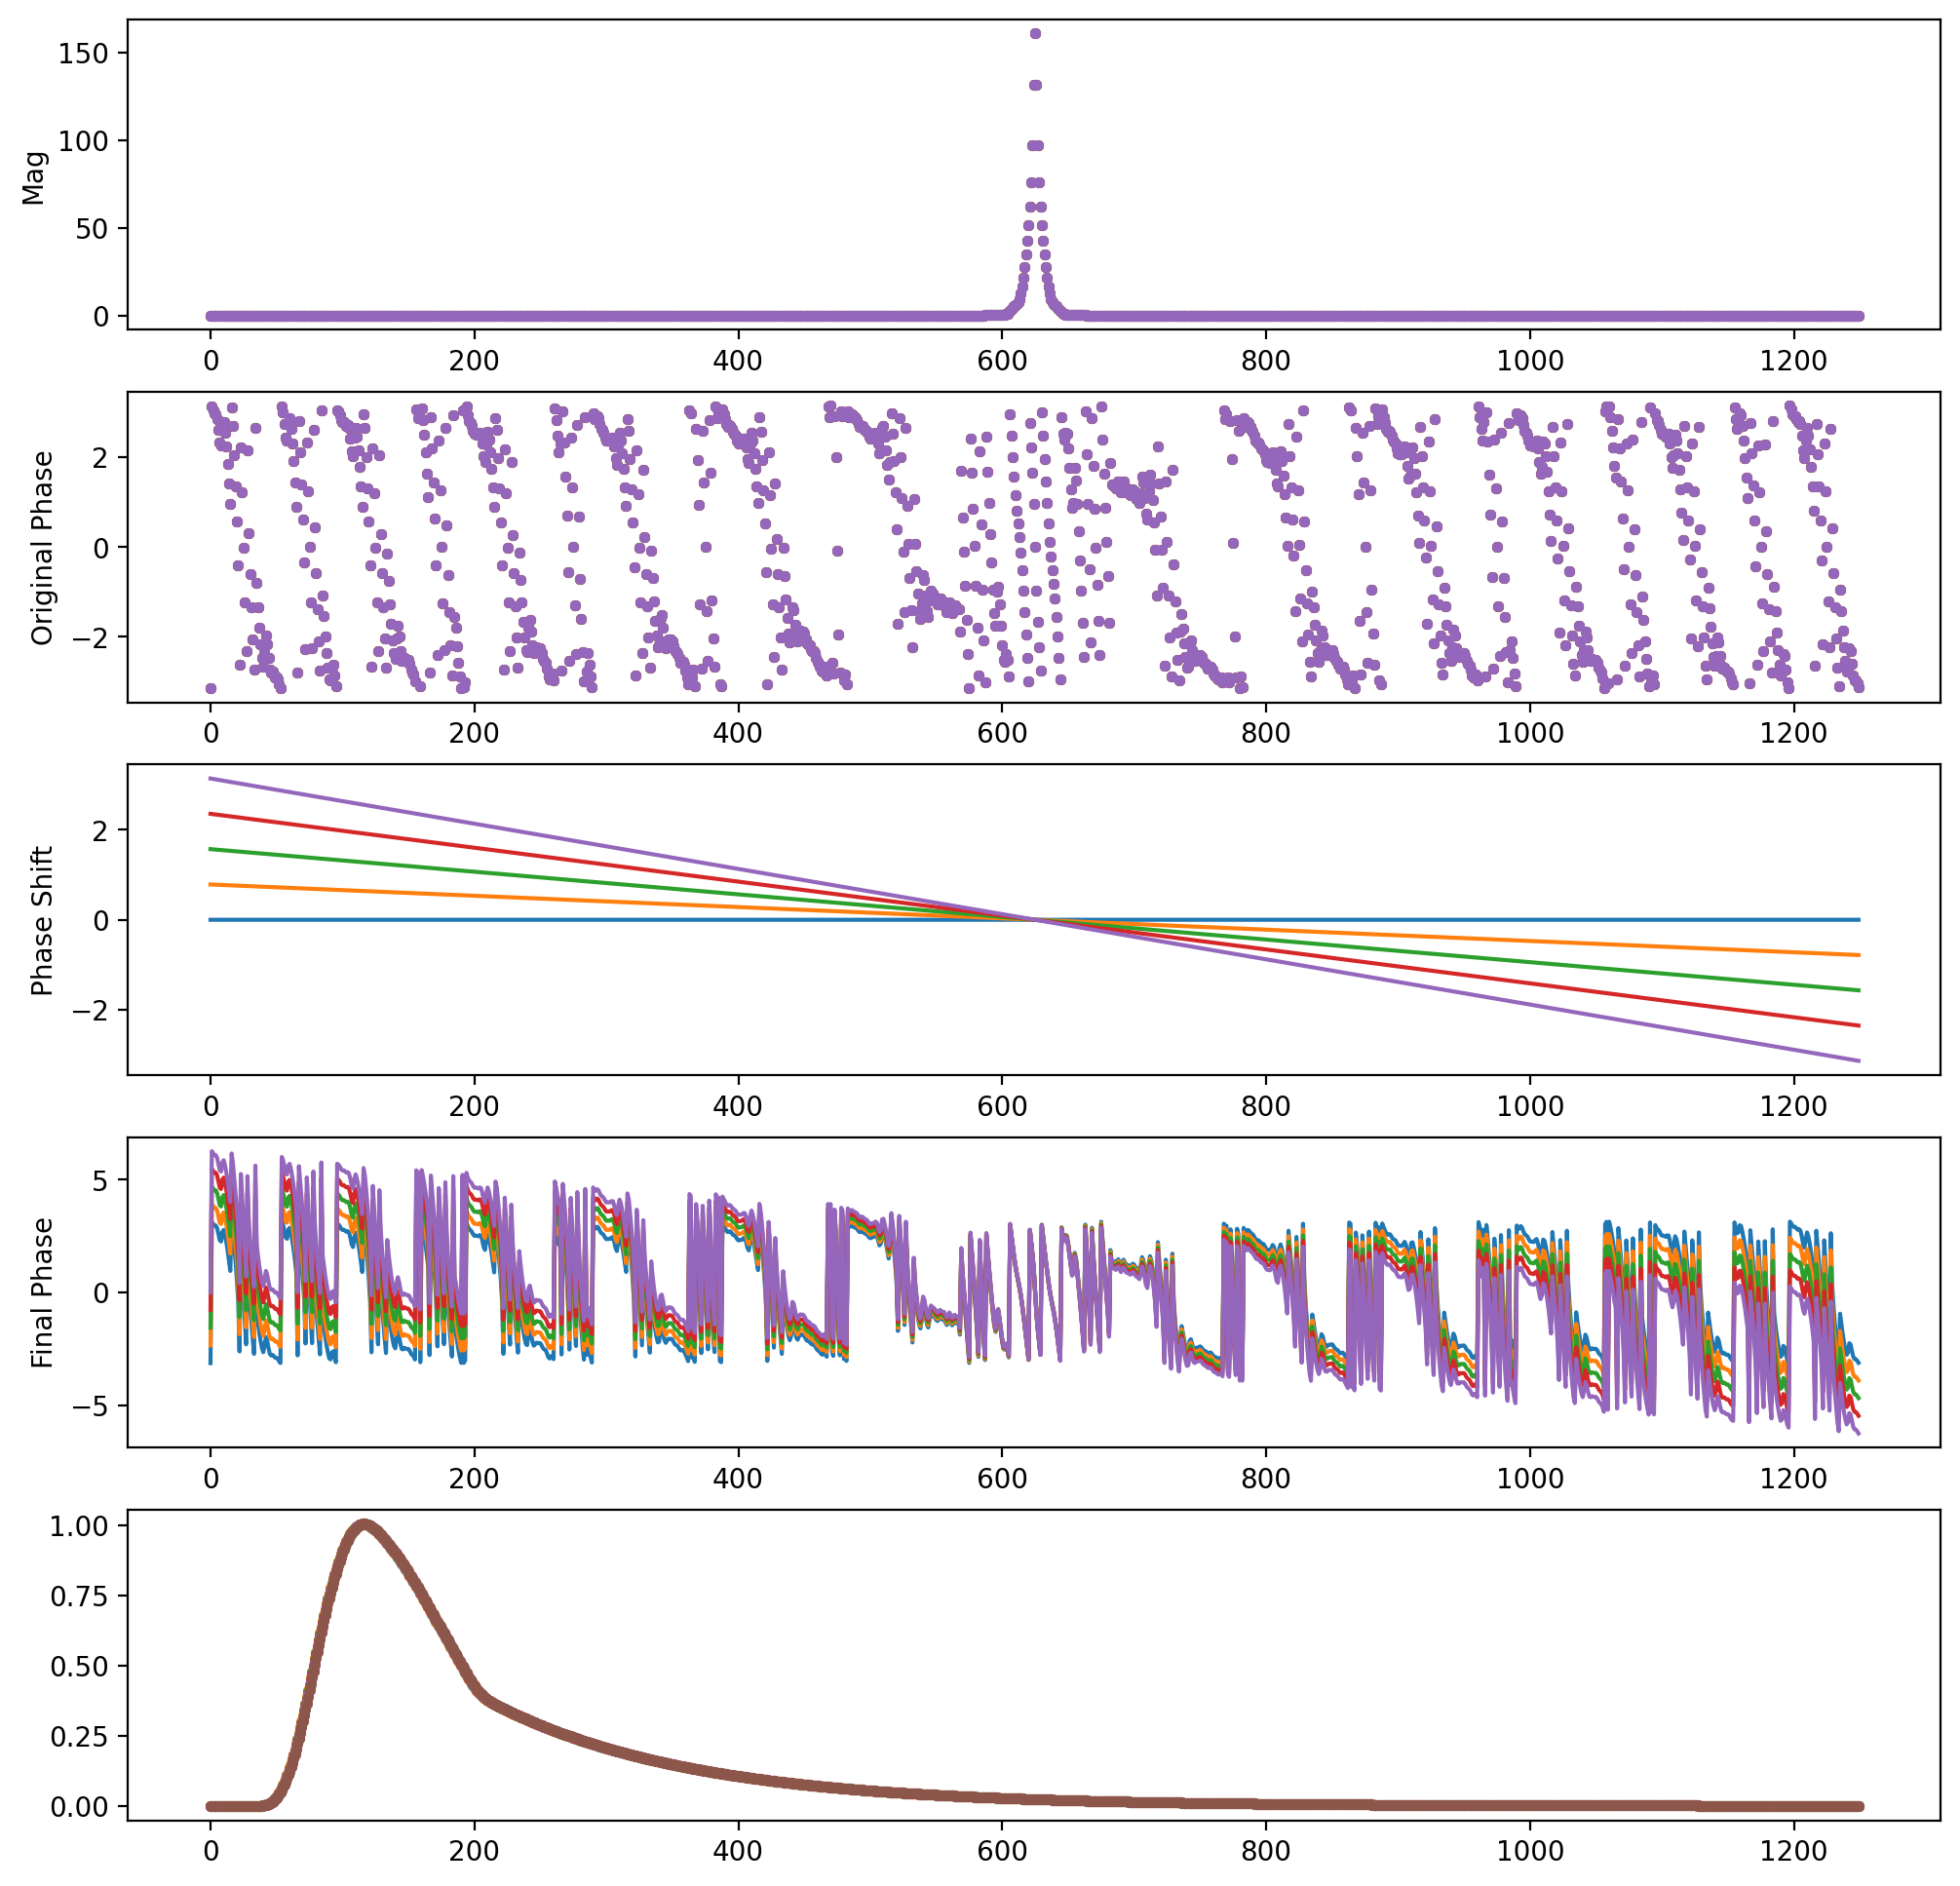

In [4]:
pulse = np.concatenate((np.zeros(interp_pulse.size), interp_pulse[:100], np.zeros(interp_pulse.size)))
base_time = np.arange(interp_pulse.size)
z = scipy.fft.fft(interp_pulse)

sample_shifts = np.linspace(0, 1, 5)

fig, axes = plt.subplots(5, 1, figsize=(12,12), dpi=200)
axes[4].plot(base_time, interp_pulse, label='original')
    
for shift in sample_shifts:
    mag, angle, whole_fft_spectrum_phase_shift, phase_shifted, complex_shifted = sample_shift_to_phase_shift(shift, z, return_extra=True)
    td_phase_shifted = np.real(scipy.fft.ifft(complex_shifted))

    axes[0].plot(mag, '.', label=shift)
    axes[1].plot(angle, '.', label=shift)
    axes[2].plot(whole_fft_spectrum_phase_shift, label=shift)
    axes[3].plot(phase_shifted, label=shift)
    axes[4].plot(base_time, td_phase_shifted, '.', label=shift)

axes[0].set_ylabel('Mag')
axes[1].set_ylabel('Original Phase')
axes[2].set_ylabel('Phase Shift')
axes[3].set_ylabel('Final Phase')
# axes[4].set_xlim(400, 600)

# https://wirelesspi.com/effect-of-time-shift-in-frequency-domain/


1000 1000 1000
(1252,)
kernel sum 160.84872004310049
Trace Size: 51250


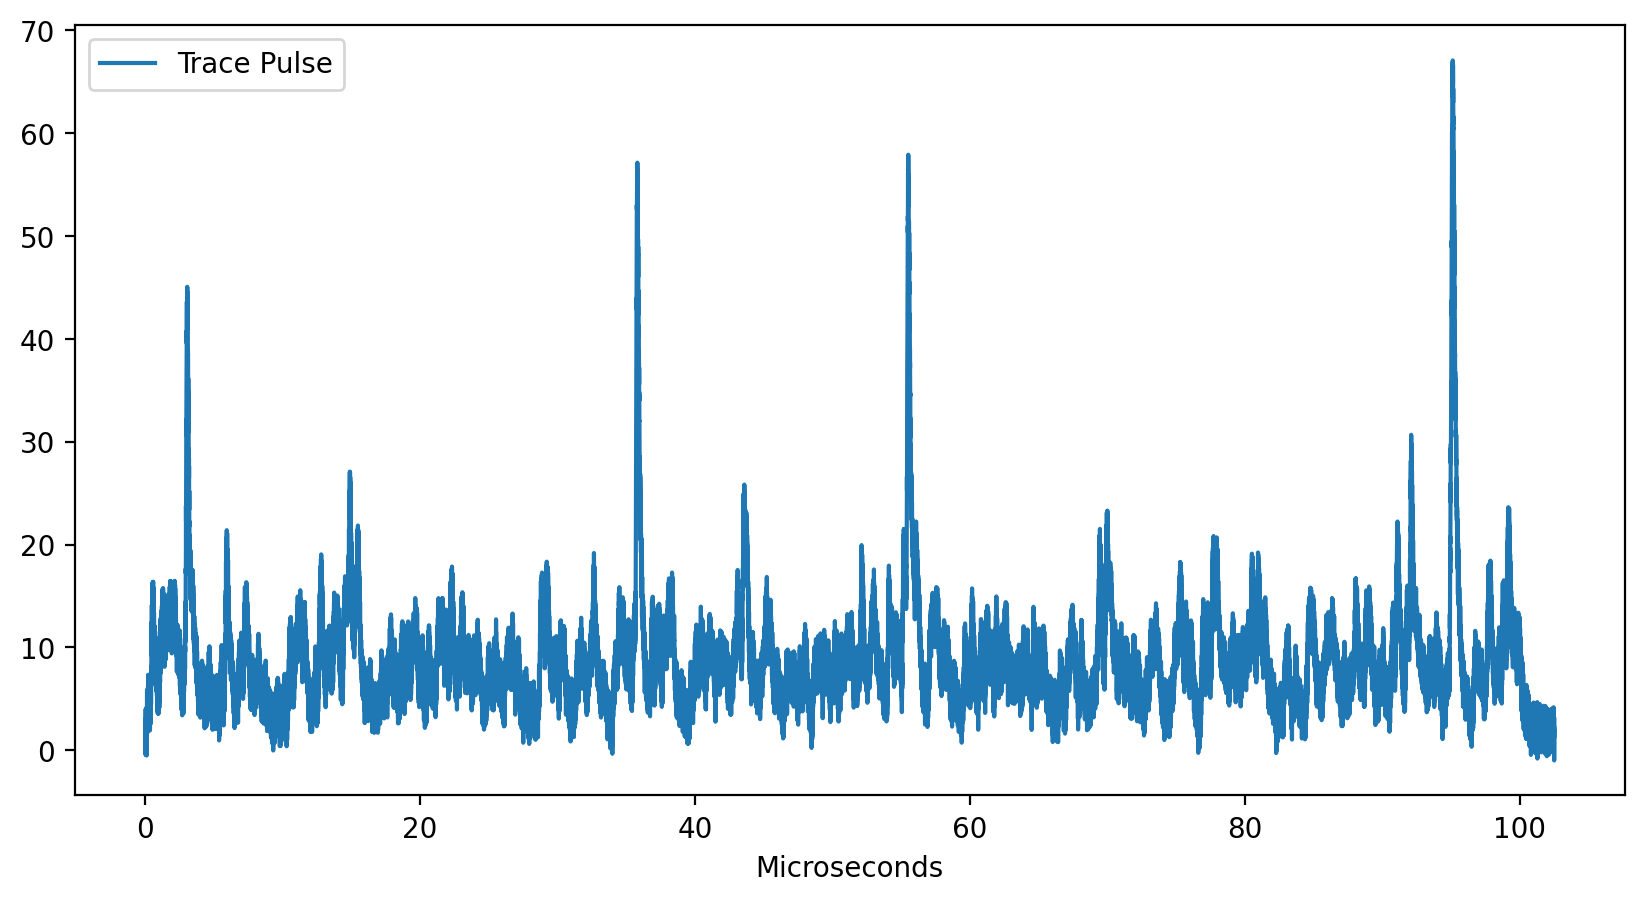

In [5]:
#determined by trial and error to match energy range of instrument on THOR data.
# modified for sampling rate difference with HERA

keV_per_area = .147
mV_per_ADC = 1000/4096
baseline = 100
basenoise = 1 #units mV
bits = 32
clip = 1000

# for Lognormal traces
fwhm = 50 #50.0 #fwhm of the total TGF count distribution in units microseconds
mean = .007 #.7 #mean of the TGF trace distribution
std = 0 #.5 #determines the amount of assymetry in the TGF trace distribution

response_file = '../original/NaI_Response'
spectrum = np.loadtxt(response_file,usecols=(1),dtype=float) # histogram density, unitless
binenergies = np.loadtxt(response_file,usecols=(0),dtype=float) * 1e3 # [KeV]

# 2000E6 seems right at the moment, but why?
fs = 500E6 # new HERA sampling rate
out = continuous_time_trace(interp_pulse, binenergies, spectrum, mV_per_ADC, keV_per_area,
                            fs=fs, count_rate=1E7, total_time=1E-4, trace_type='constant', spectrum_interp_bins=4,
                            lognormal_mean=mean, lognormal_std=std, lognormal_fwhm=fwhm,
                            baseline=basenoise, basenoise=basenoise, bits=bits, clip_magnitude=clip, 
                            seed=1,)

trace, sample_t, sample_index, event_voltages, event_energies, event_times = out

print('Trace Size:', trace.size)

trace_gt0 = trace[trace>0]

plt.figure(figsize=(10,5), dpi=200)
plt.plot(1E6*sample_t, trace, label='Trace Pulse')
# plt.plot(1E6*interp_time, interp_pulse * np.max(trace), '.', markersize=1, alpha=.5, label='Interp Pulse')
plt.xlabel('Microseconds')
plt.legend()


In [6]:
# Current theory is the mismatch pulse size rise due to mismatch between fs, original re-sampling and f domain interp

In [7]:
# TODO might also add finer interpolation of the possible energy bins...

# It should be noted that the superior resolving time of the plastic response as opposed to Nai Would make it superior at estimating countrates...

#alternative idea: numerical optimization of [times,volts] on continuous values optimized by TD.